# 02 - Comparaison et selection du modele

Objectif : comparer Linear Regression, Random Forest et XGBoost avec le meme jeu de test, selectionner le meilleur selon le RMSE et l'enregistrer dans `models/model.pkl`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
# Localisation independante du dossier de lancement
project_candidates = [Path.cwd(), Path.cwd().parent]
project_root = next(
    (path for path in project_candidates if (path / "data" / "raw" / "BostonHousing.csv").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("data/raw/BostonHousing.csv introuvable")

data_path = project_root / "data" / "raw" / "BostonHousing.csv"
model_path = project_root / "models" / "model.pkl"
df = pd.read_csv(data_path)
print(f"Dataset : {data_path.resolve()}")

Dataset : C:\Users\pc\openhousing-mlops\data\raw\BostonHousing.csv


## Preparation

`medv` est convertie en USD. La variable sensible `b` est exclue. Chaque modele utilise un pipeline avec imputation mediane afin d'eviter toute fuite de donnees.

In [3]:
TARGET = "medv"
EXCLUDED_FEATURES = ["b"]

y = df[TARGET] * 1_000
X = df.drop(columns=[TARGET, *EXCLUDED_FEATURES])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Variables ({X.shape[1]}) : {X.columns.tolist()}")
print(f"Train : {len(X_train)} | Test : {len(X_test)}")

Variables (12) : ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
Train : 404 | Test : 102


In [4]:
estimators = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

models = {
    name: Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("regressor", estimator),
    ])
    for name, estimator in estimators.items()
}

## Entrainement et comparaison

In [5]:
results = []
predictions = {}

for name, candidate in models.items():
    candidate.fit(X_train, y_train)
    prediction = candidate.predict(X_test)
    predictions[name] = prediction
    results.append({
        "Modele": name,
        "MAE (USD)": mean_absolute_error(y_test, prediction),
        "RMSE (USD)": mean_squared_error(y_test, prediction) ** 0.5,
        "R2": r2_score(y_test, prediction),
    })

comparison = pd.DataFrame(results).sort_values("RMSE (USD)").reset_index(drop=True)
display(comparison.style.format({"MAE (USD)": "{:,.2f}", "RMSE (USD)": "{:,.2f}", "R2": "{:.4f}"}))

,Modele,MAE (USD),RMSE (USD),R2
0,XGBoost,"1,828.98","2,750.60",0.8968
1,Random Forest,"2,035.88","2,953.36",0.8811
2,Linear Regression,"3,111.38","4,772.60",0.6894


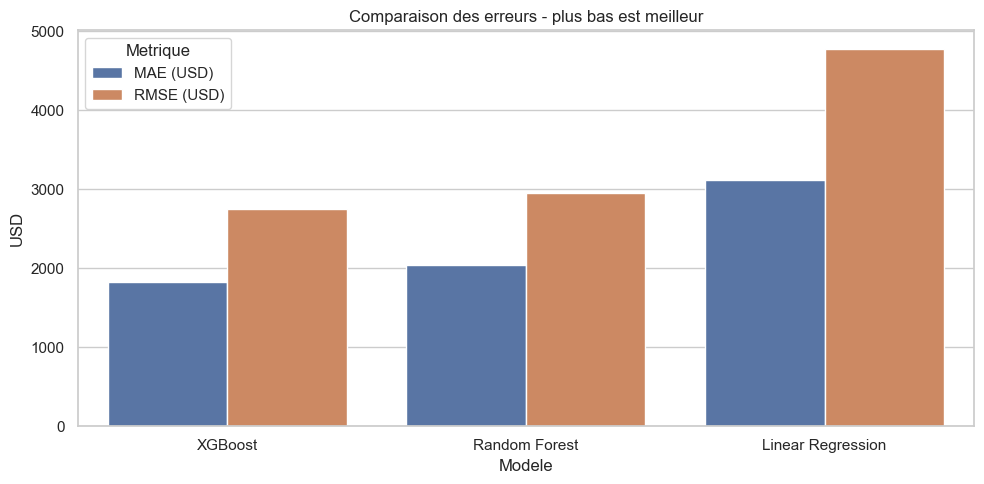

In [6]:
metrics_long = comparison.melt(
    id_vars="Modele", value_vars=["MAE (USD)", "RMSE (USD)"],
    var_name="Metrique", value_name="USD"
)
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x="Modele", y="USD", hue="Metrique")
plt.title("Comparaison des erreurs - plus bas est meilleur")
plt.tight_layout()
plt.show()

## Selection et sauvegarde

In [7]:
best_name = comparison.iloc[0]["Modele"]
best_model = models[best_name]
best_prediction = predictions[best_name]

model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_path)

print(f"Meilleur modele selon le RMSE : {best_name}")
print(f"Modele enregistre : {model_path.resolve()}")
print(f"Taille : {model_path.stat().st_size:,} octets")

Meilleur modele selon le RMSE : XGBoost
Modele enregistre : C:\Users\pc\openhousing-mlops\models\model.pkl
Taille : 469,330 octets


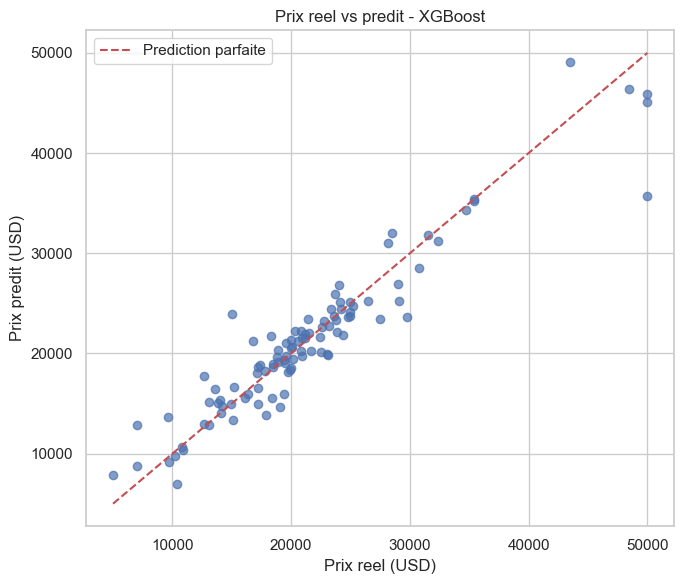

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_prediction, alpha=0.7)
limits = [min(y_test.min(), best_prediction.min()), max(y_test.max(), best_prediction.max())]
plt.plot(limits, limits, "r--", label="Prediction parfaite")
plt.xlabel("Prix reel (USD)")
plt.ylabel("Prix predit (USD)")
plt.title(f"Prix reel vs predit - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## Diagnostic du meilleur modele

Les erreurs sont analysees uniquement apres la selection, sur le jeu de test qui n'a pas servi a l'entrainement.

In [9]:
prediction_details = pd.DataFrame({
    "Prix reel (USD)": y_test.to_numpy(),
    "Prix predit (USD)": best_prediction,
})
prediction_details["Erreur (USD)"] = (
    prediction_details["Prix reel (USD)"] - prediction_details["Prix predit (USD)"]
)
prediction_details["Erreur absolue (USD)"] = prediction_details["Erreur (USD)"].abs()

display(prediction_details.head(10).round(2))

,Prix reel (USD),Prix predit (USD),Erreur (USD),Erreur absolue (USD)
0,23600.0,23755.970703,-155.97,155.97
1,32400.0,31255.669922,1144.33,1144.33
2,13600.0,16472.060547,-2872.06,2872.06
3,22800.0,23201.320312,-401.32,401.32
4,16100.0,15568.839844,531.16,531.16
5,20000.0,21371.980469,-1371.97,1371.97
6,17800.0,18242.960938,-442.96,442.96
7,14000.0,15342.360352,-1342.36,1342.36
8,19600.0,21011.300781,-1411.30,1411.30
9,16800.0,21222.369141,-4422.37,4422.37


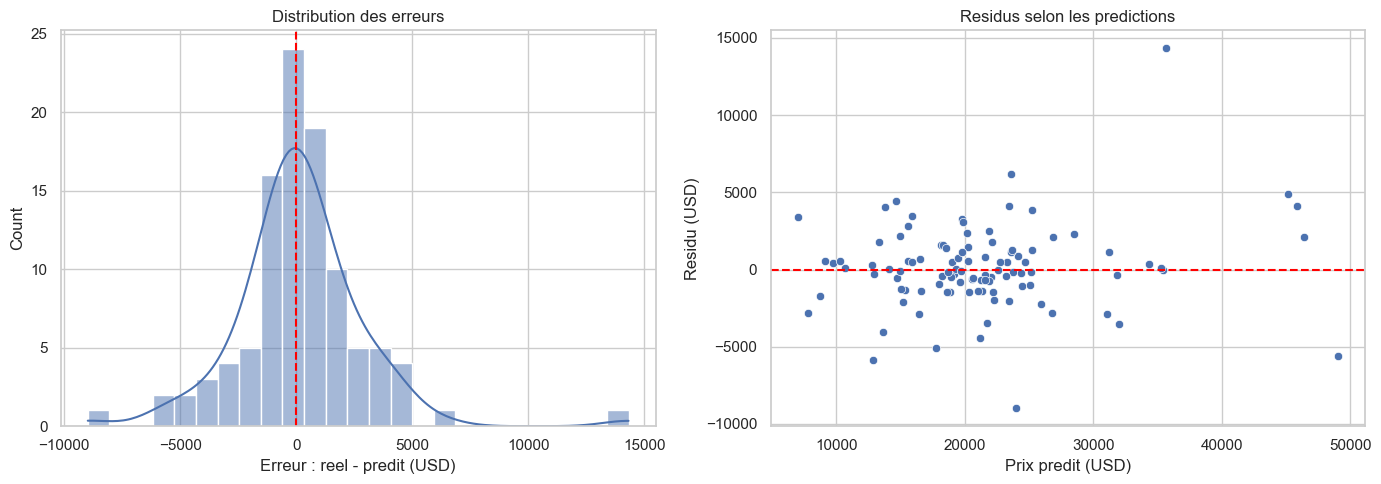

Erreur moyenne : 132.28 USD


In [10]:
residuals = y_test.to_numpy() - best_prediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, bins=25, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set(title="Distribution des erreurs", xlabel="Erreur : reel - predit (USD)")

sns.scatterplot(x=best_prediction, y=residuals, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(
    title="Residus selon les predictions",
    xlabel="Prix predit (USD)",
    ylabel="Residu (USD)",
)
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {residuals.mean():,.2f} USD")

## Importance des variables par permutation

Cette methode est independante du type de modele et mesure la degradation du score lorsque chaque variable est melangee. Elle est donc plus comparable qu'une importance native propre a XGBoost.

,Variable,Importance moyenne,Ecart-type
0,lstat,3878.155963,482.248313
1,rm,3048.287172,240.213915
2,dis,971.547202,216.061252
3,crim,632.706448,170.744701
4,nox,534.680261,104.702391
5,age,417.598321,78.350741
6,ptratio,323.212921,67.619442
7,tax,157.520714,55.210780
8,rad,65.318598,32.714640
9,zn,25.818415,6.350560


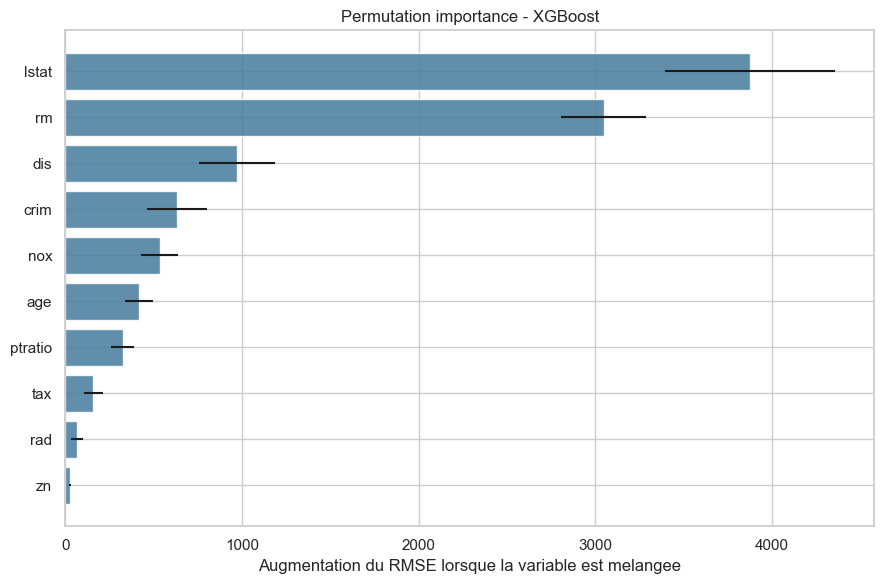

In [11]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance = (
    pd.DataFrame({
        "Variable": X.columns,
        "Importance moyenne": permutation.importances_mean,
        "Ecart-type": permutation.importances_std,
    })
    .sort_values("Importance moyenne", ascending=False)
    .reset_index(drop=True)
)
display(importance)

plot_data = importance.head(10).sort_values("Importance moyenne")
plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["Variable"],
    plot_data["Importance moyenne"],
    xerr=plot_data["Ecart-type"],
    color="#457b9d",
    alpha=0.85,
)
plt.xlabel("Augmentation du RMSE lorsque la variable est melangee")
plt.title(f"Permutation importance - {best_name}")
plt.tight_layout()
plt.show()

In [12]:
# Verification immediate de l'artefact sauvegarde
loaded_model = joblib.load(model_path)
example_prediction = loaded_model.predict(X_test.iloc[[0]])[0]
print(f"Test de rechargement reussi - estimation : {example_prediction:,.2f} USD")

Test de rechargement reussi - estimation : 23,755.97 USD
